# 1. Project Overview
# ============================================
# Data Mining Project — Telco Customer Churn
# Algorithm: Decision Tree vs Random Forest
# Framework: CRISP-DM
# ============================================

# 2. Import The Libraries

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# 3. Data Acquisition

Dataset: Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In this step, we use the `google.colab` library to upload the raw dataset and load it into a pandas DataFrame using an IO stream.

In [2]:
# Load dataset from local file
from google.colab import files
uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Please run this cell again and select the CSV file.")
else:
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"Dataset '{filename}' loaded successfully")
    print(f"Shape: {df.shape}")
    display(df.head())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Dataset 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv' loaded successfully
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#  4. Exploratory Data Analysis (EDA) — Audit
We perform an initial audit of the dataset to check for schema consistency, missing values, and duplicate records.

In [3]:
# Diagnostic EDA — info, nulls, duplicates, statistics
print("===== BASIC INFO =====")
print(df.info())

print("\n===== NULL VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATES =====")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n===== STATISTICAL SUMMARY =====")
display(df.describe())

===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#  5. Exploratory Data Analysis (EDA) — Visualizations
In this section, we visualize the distribution of the target variable and analyze correlations.

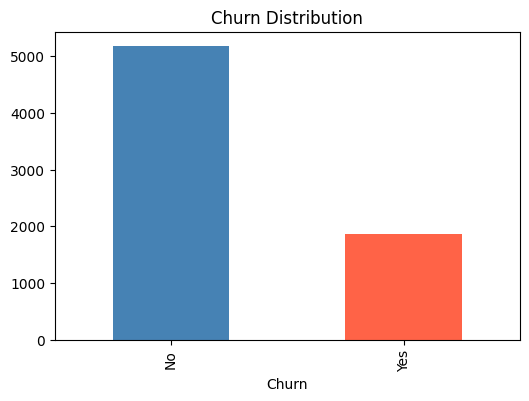

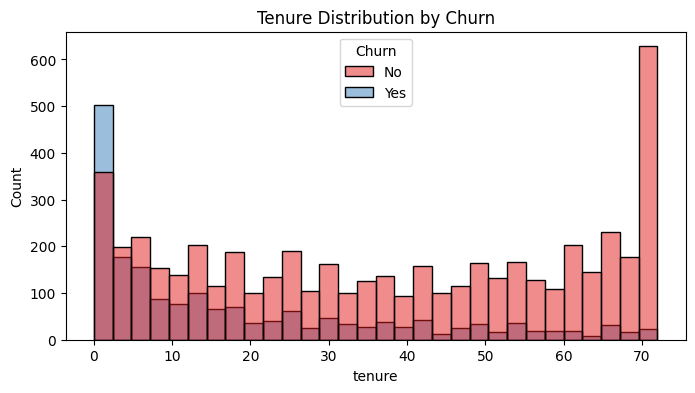

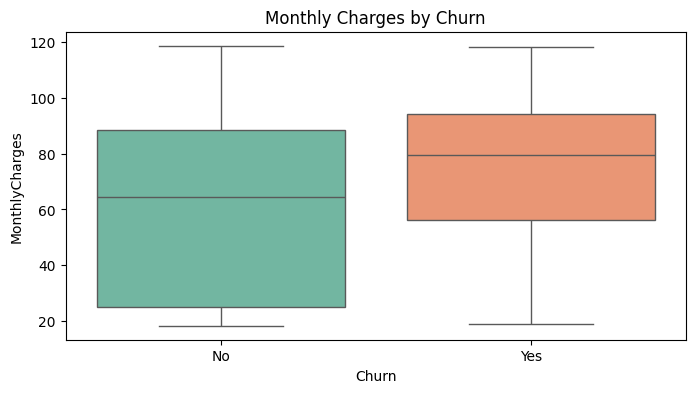

In [4]:
# Visual EDA — churn distribution, tenure, monthly charges
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set1')
plt.title('Tenure Distribution by Churn')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.show()

#  6. Data Cleansing
We handle data type conversions, remove irrelevant features, and map our target variable.

In [5]:
# Clean TotalCharges, drop customerID, encode target column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"Clean dataset shape: {df.shape}")

Clean dataset shape: (7032, 20)


#  7. Encoding
We convert all remaining categorical text columns into numeric values using LabelEncoder.

In [6]:
# Encode categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Columns being encoded: {categorical_cols}")

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

Columns being encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


# 8. Dataset Splitting

In [7]:
# Split into training and testing sets
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (5625, 19)
Testing set:  (1407, 19)


# 9. Model Training: Decision Tree

In [8]:
# Train Decision Tree and evaluate
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("===== DECISION TREE RESULTS =====")
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, dt_pred):.4f}")

===== DECISION TREE RESULTS =====
Accuracy:  0.7249
Precision: 0.4838
Recall:    0.5187
F1 Score:  0.5006


# 10. Model Training: Random Forest

In [9]:
# Train Random Forest and evaluate
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("===== RANDOM FOREST RESULTS =====")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.4f}")

===== RANDOM FOREST RESULTS =====
Accuracy:  0.7925
Precision: 0.6444
Recall:    0.4893
F1 Score:  0.5562


#  11. Performance Evaluation
Comparing both models across all metrics and visualizing the results.

## 11.1 Model Comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.724947,0.792466
1,Precision,0.483791,0.644366
2,Recall,0.518717,0.489305
3,F1 Score,0.500645,0.556231


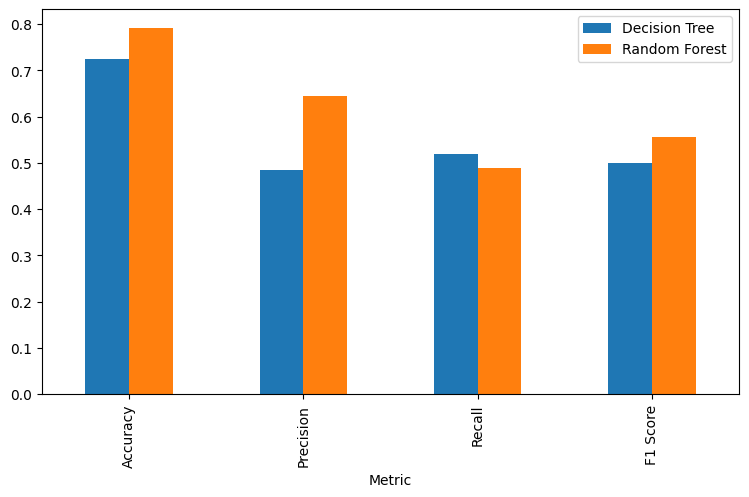

In [10]:
# Compare model metrics side by side
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Decision Tree': [accuracy_score(y_test, dt_pred), precision_score(y_test, dt_pred), recall_score(y_test, dt_pred), f1_score(y_test, dt_pred)],
    'Random Forest': [accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred), recall_score(y_test, rf_pred), f1_score(y_test, rf_pred)]
})
display(comparison)
comparison.set_index('Metric').plot(kind='bar', figsize=(9,5))
plt.show()

# 11.2 Feature Importance

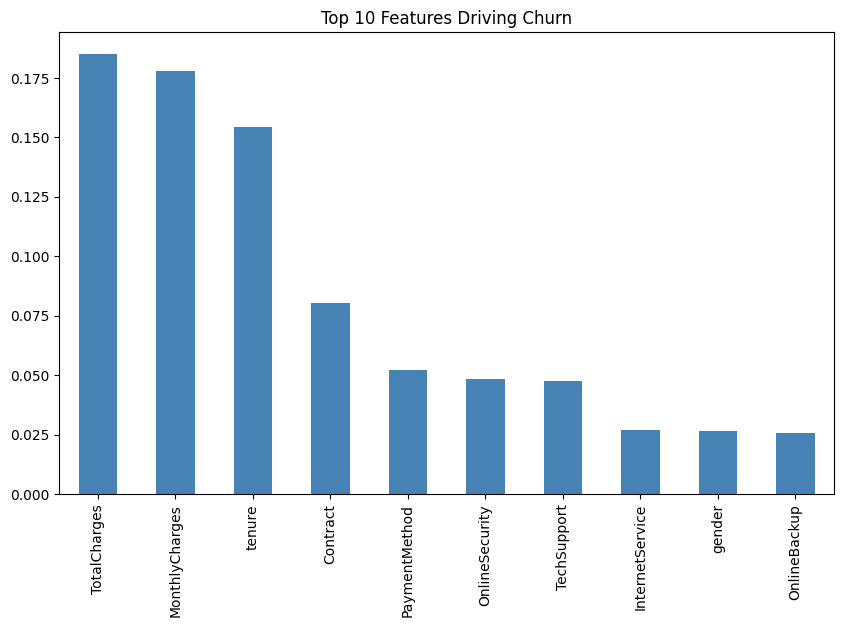

In [11]:
# Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Features Driving Churn')
plt.show()

# 11.3 Confusion Matrix

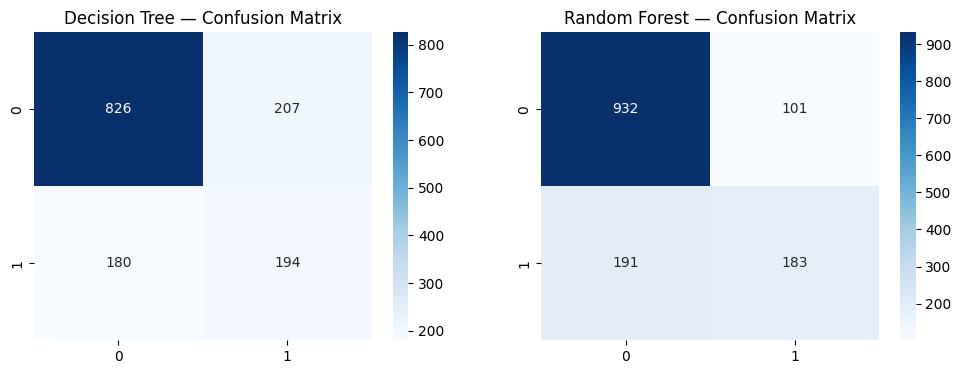

In [12]:
# Confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, pred, title in zip(axes, [dt_pred, rf_pred], ['Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{title} — Confusion Matrix')
plt.show()

# 12. Export Cleaned Dataset

In [13]:
# Export cleaned dataset to CSV
df.to_csv('telco_churn_cleaned.csv', index=False)
from google.colab import files
files.download('telco_churn_cleaned.csv')
print("Cleaned dataset exported successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaned dataset exported successfully.
